# Author: Xiaopeng ZHANG
# Project: vp_sde_ode
# Date: May 4th 2026

VP Diffusion SDE vs Backward Probability-Flow ODE, code `vp_sde_ode`

This notebook implements the forward SDE (5), the analytic density/score formulas (7)--(9), and the backward probability-flow ODE (10). It compares empirical marginals using overlaid histograms at aligned snapshot times.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# Parameters from the subject.
T = 2.0
beta = 1.0
n_sde = 100_000
n_T = 10
dt = 1.0e-3
n_ode = 5_000
epsilon = 1.0e-3
random_seed = 42
n_bins = 80
x_min = -3.5
x_max = 3.5

## Analytic formulas used from the statement

The next cells implement the provided expressions directly: formula (6) for `a(t)` and `s(t)`, formula (7) for `p_t(x)`, formula (8) for `p_t'(x)`, and formula (9) for the score. The standard normal CDF/PDF are called directly as `scipy.stats.norm.cdf` and `scipy.stats.norm.pdf`.


In [3]:
def a_t(t, beta_value):
    """Formula (6): a(t) = exp(-beta t / 2)."""
    return np.exp(-0.5 * beta_value * t)


def s_t(t, beta_value):
    """Formula (6): s(t) = sqrt(1 - exp(-beta t))."""
    return np.sqrt(1.0 - np.exp(-beta_value * t))


In [4]:
def p_density(t, x, beta_value):
    """Formula (7): analytic marginal density p_t(x), t > 0."""
    a_value = a_t(t, beta_value)
    s_value = s_t(t, beta_value)
    term = (
        norm.cdf((x + 2.0 * a_value) / s_value)
        - norm.cdf((x + a_value) / s_value)
        + norm.cdf((x - a_value) / s_value)
        - norm.cdf((x - 2.0 * a_value) / s_value)
    )
    return term / (2.0 * a_value)


def p_density_derivative(t, x, beta_value):
    """Formula (8): analytic spatial derivative p'_t(x), t > 0."""
    a_value = a_t(t, beta_value)
    s_value = s_t(t, beta_value)
    term = (
        norm.pdf((x + 2.0 * a_value) / s_value)
        - norm.pdf((x + a_value) / s_value)
        + norm.pdf((x - a_value) / s_value)
        - norm.pdf((x - 2.0 * a_value) / s_value)
    )
    return term / (2.0 * a_value * s_value)


def score(t, x, beta_value, density_floor=1.0e-12):
    """Formula (9): analytic score partial_x log p_t(x) = p'_t(x) / p_t(x)."""
    density = np.maximum(p_density(t, x, beta_value), density_floor)
    return p_density_derivative(t, x, beta_value) / density


def probability_flow_rhs(t, y, beta_value):
    """Formula (10): probability-flow ODE right-hand side, vectorized over trajectories."""
    return -0.5 * beta_value * y - 0.5 * beta_value * score(t, y, beta_value)


In [5]:
def sample_p0(size):
    """Sample p0 = 1/2 Unif[-2,-1] + 1/2 Unif[1,2] using NumPy."""
    component = np.random.randint(0, 2, size=size)
    magnitude = np.random.uniform(1.0, 2.0, size=size)
    return np.where(component == 0, -magnitude, magnitude)


n_steps = int(round(T / dt))
actual_T = n_steps * dt
if not np.isclose(actual_T, T):
    raise ValueError("T must be an integer multiple of dt for aligned snapshots.")

# Log-uniform-like snapshot grid, aligned with Euler steps. Step 0 is handled separately.
positive_snapshot_steps = np.unique(np.round(np.geomspace(1, n_steps, n_T)).astype(int))
positive_snapshot_steps[-1] = n_steps
snapshot_steps = np.r_[0, positive_snapshot_steps]
snapshot_times = snapshot_steps * dt

# All random sampling in this notebook uses NumPy's random functions.
np.random.seed(random_seed)
print("snapshot times:", np.round(snapshot_times, 4))


snapshot times: [0.00e+00 1.00e-03 2.00e-03 5.00e-03 1.30e-02 2.90e-02 6.80e-02 1.59e-01
 3.69e-01 8.60e-01 2.00e+00]


In [6]:
def simulate_forward_sde(n_trajectories):
    """Euler-Maruyama simulation of formula (5)."""
    X = sample_p0(n_trajectories)
    stored = {0: X.copy()}
    snapshot_lookup = set(positive_snapshot_steps.tolist())

    drift_factor = 1.0 - 0.5 * beta * dt
    diffusion_scale = np.sqrt(beta * dt)
    for step in range(1, n_steps + 1):
        X = drift_factor * X + diffusion_scale * np.random.normal(size=n_trajectories)
        if step in snapshot_lookup:
            stored[step] = X.copy()
    return stored


forward_samples = simulate_forward_sde(n_sde)
print(f"stored {len(forward_samples)} forward snapshots")


stored 11 forward snapshots


In [7]:
def simulate_backward_ode(n_trajectories):
    """Vectorized Heun integration of formula (10), backward from T to epsilon."""
    Y = np.random.normal(size=n_trajectories)
    stored = {n_steps: Y.copy()}
    positive_lookup = set(positive_snapshot_steps.tolist())

    # The ODE is evaluated only for t >= epsilon. With dt=epsilon, step 1 is t=epsilon.
    for step in range(n_steps, 1, -1):
        t_now = step * dt
        h = -dt
        k1 = probability_flow_rhs(t_now, Y, beta)
        predictor = Y + h * k1
        k2 = probability_flow_rhs(t_now + h, predictor, beta)
        Y = Y + 0.5 * h * (k1 + k2)
        new_step = step - 1
        if new_step in positive_lookup:
            stored[new_step] = Y.copy()

    # For plotting at t=0, use the epsilon snapshot as the ODE approximation.
    stored[0] = stored.get(1, Y.copy())
    return stored


ode_samples = simulate_backward_ode(n_ode)
print(f"stored {len(ode_samples)} backward ODE snapshots")


stored 11 backward ODE snapshots


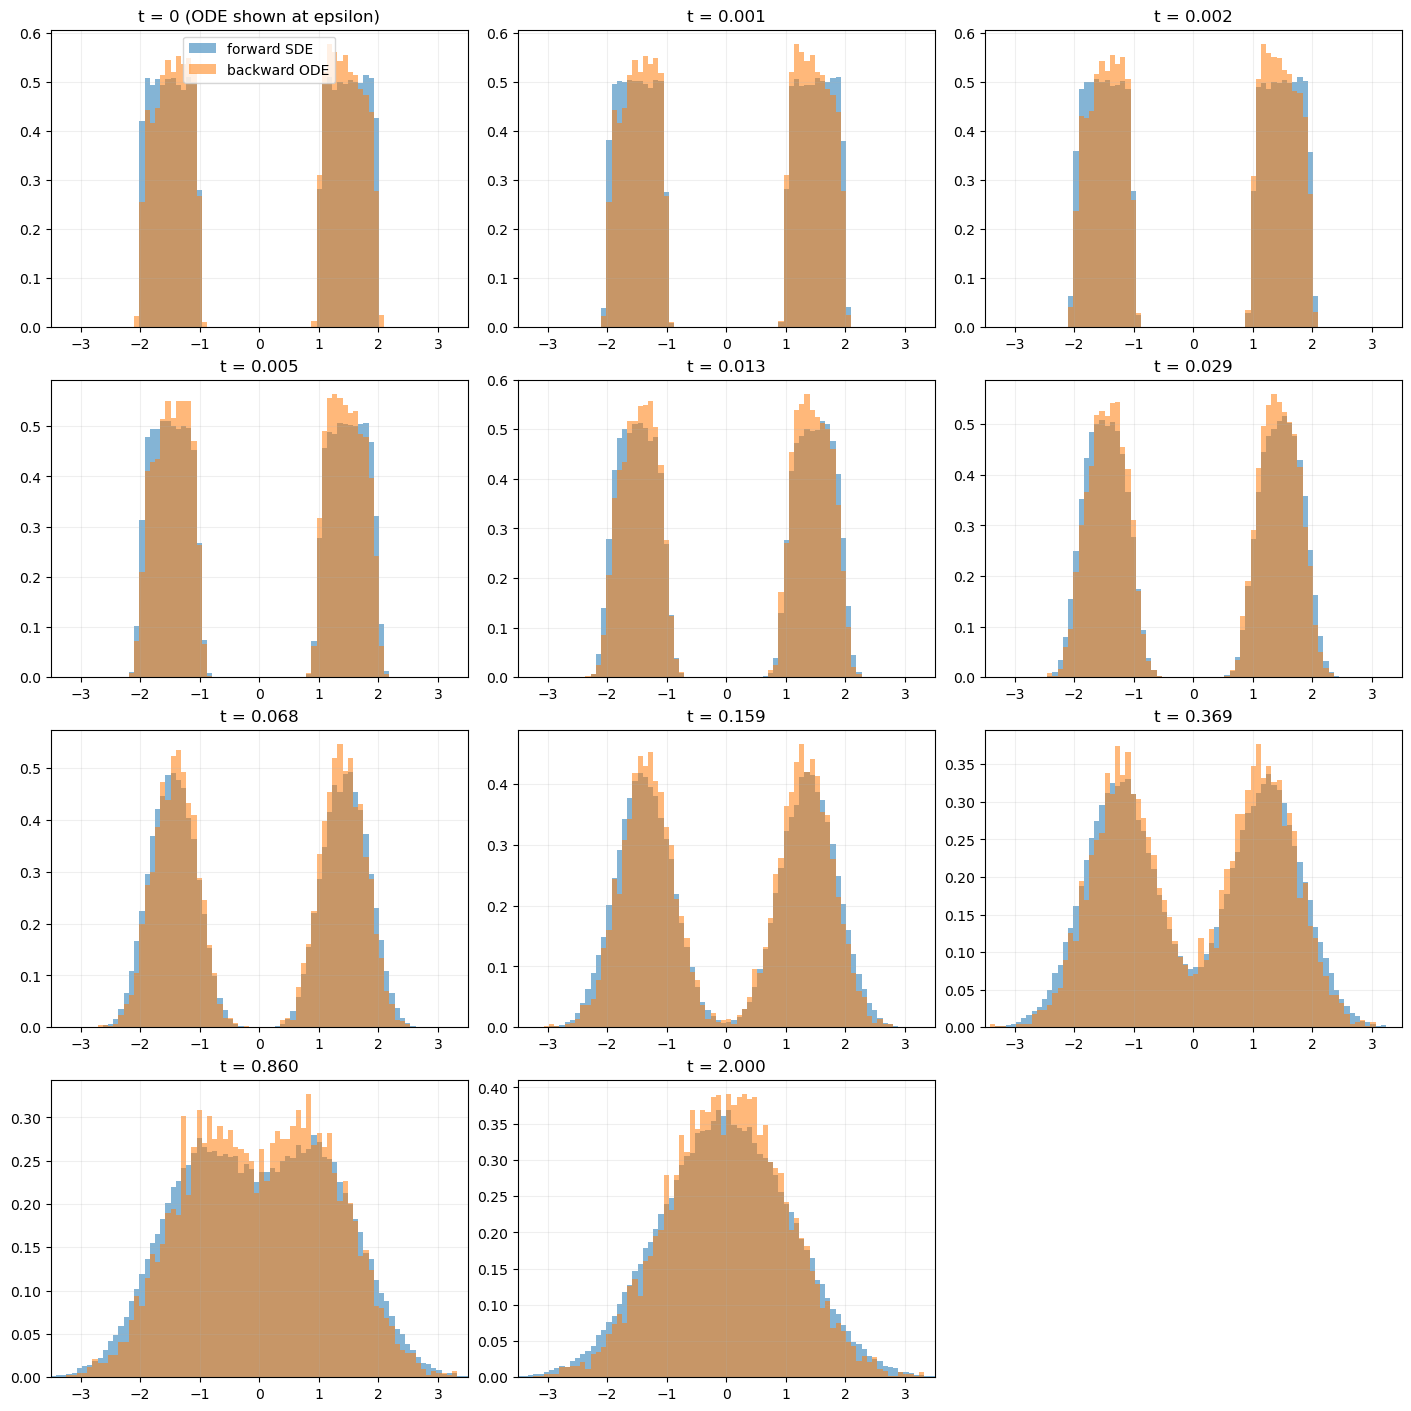

In [8]:
plot_steps = snapshot_steps
bins = np.linspace(x_min, x_max, n_bins + 1)
columns = 3
rows = int(np.ceil(plot_steps.size / columns))
fig, axes = plt.subplots(rows, columns, figsize=(14, 3.5 * rows), constrained_layout=True)
axes = np.ravel(axes)

for axis, step in zip(axes, plot_steps):
    ode_step = step if step in ode_samples else 0
    axis.hist(
        forward_samples[step], bins=bins, density=True, alpha=0.55,
        label="forward SDE", color="tab:blue",
    )
    axis.hist(
        ode_samples[ode_step], bins=bins, density=True, alpha=0.55,
        label="backward ODE", color="tab:orange",
    )
    axis.set_xlim(x_min, x_max)
    axis.set_title("t = 0 (ODE shown at epsilon)" if step == 0 else f"t = {step * dt:.3f}")
    axis.grid(True, alpha=0.2)

for axis in axes[plot_steps.size:]:
    axis.axis("off")

axes[0].legend()
plt.show()


In [9]:
# Numerical summary: compare means and variances at each stored time.
print("time      mean SDE    mean ODE    var SDE     var ODE")
for step in plot_steps:
    ode_step = step if step in ode_samples else 0
    x_values = forward_samples[step]
    y_values = ode_samples[ode_step]
    print(
        f"{step * dt:6.3f}  "
        f"{x_values.mean():9.4f}  {y_values.mean():9.4f}  "
        f"{x_values.var():9.4f}  {y_values.var():9.4f}"
    )

time      mean SDE    mean ODE    var SDE     var ODE
 0.000     0.0028     0.0281     2.3362     2.2415
 0.001     0.0027     0.0281     2.3346     2.2415
 0.002     0.0026     0.0281     2.3329     2.2396
 0.005     0.0024     0.0279     2.3290     2.2339
 0.013     0.0020     0.0277     2.3192     2.2192
 0.029     0.0022     0.0272     2.2982     2.1910
 0.068     0.0025     0.0263     2.2503     2.1266
 0.159     0.0028     0.0246     2.1420     1.9925
 0.369     0.0012     0.0217     1.9233     1.7424
 0.860    -0.0043     0.0181     1.5677     1.3620
 2.000    -0.0041     0.0147     1.1853     0.9969


## Observation

The overlaid histograms should be close because the probability-flow ODE is built with the exact score of the forward VP diffusion. It transports probability mass with the same marginal laws as the SDE when initialized from the correct terminal marginal. The PDF asks us to sample `Y_T` from a standard normal law; at finite `T = 2`, the true `p_T` is close to but not exactly standard normal, so small discrepancies are expected in addition to Monte Carlo error, time discretization error, and finite precision in the SciPy normal CDF/PDF evaluations.